In [9]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from astropy.io import fits
import os
import json
import odos.optimal_period as op

In [ ]:
pl_nam = 'TOI-2076.02'
with open('2076c_params.json', 'r') as f:
    pp = json.load(f)


In [12]:
### OBSERVATIONAL PARAMETERS ###
TRANSIT_DURATION = pp['transit_duration']


## CALCULATE TRANSIT FOR START AND END DATE IN BJD ##
OBSERV_START= '2025-10-01'
OBSERV_END = '2025-10-28'

## OBSERVATORY PARAMETERS ##
###TEIDE OBSERVATORY ###
OBS_LAT = 28.3011
OBS_LONG = -16.5103
OBS_ALT = 2400

# MAUNA KEA OBSERVATORY ###
OBS_LAT1 = 19.8242
OBS_LONG1 = -155.477
OBS_ALT1 = 4205

OBS_LOC = [OBS_LAT,OBS_LONG,OBS_ALT]


## OBSERVATION CONSTRAINS ##
MINIMUM_ALTITUDE = 20
MINIMUM_MOON_SEPARATION = 0


In [13]:
pl_path = 'mast_data/open/'


In [14]:
def create_dummy_obs(midtime, duration):
    
    tt = np.arange(midtime - duration, midtime + duration, 2/24/60)
    flux = np.ones(len(tt))
    flux_err = flux / 500
    return tt, flux, flux_err

In [15]:
my_planet = op.UnknownPeriodPlanet(pl_nam,P_min=15,transit_duration=pp['transit_duration'], transit_depth=pp['transit_depth']/1000000)
my_planet.P_max = [pp['period'],pp['period_err']]
my_planet.reference_midtime = [pp['mid_time'],pp['mid_time_err']]

pathlist = os.listdir(pl_path)
pathlist.sort()
for file_path in pathlist:
    print(file_path)
    tess_dat = fits.open(os.path.join(pl_path, file_path))
    df231 = pd.DataFrame(tess_dat[1].data.T)
    df23 = df231[['TIME', 'PDCSAP_FLUX','PDCSAP_FLUX_ERR']]
    df23 = df23.dropna()
    df23 = df23.reset_index(drop=True)
    tim = np.array(df23['TIME'])
    flux = np.array(df23['PDCSAP_FLUX'])
    flux_err = np.array(df23['PDCSAP_FLUX_ERR'])
    my_planet.add_observation(tim + 2457000, flux, flux_err)



hlsp_tess-spoc_tess_phot_0000000027491137-s0016_tess_v1_lc.fits
Binning is not provided, assumed median binning of 30.00 minutes
hlsp_tess-spoc_tess_phot_0000000027491137-s0023_tess_v1_lc.fits
Binning is not provided, assumed median binning of 30.00 minutes


In [16]:
my_planet.t_midtimes = [[2458748.69458, 0.001], [2458937.8222, 0.1]]
my_planet.observations[0]['plot_label'] = 'TESS Sect 16'
my_planet.observations[1]['plot_label'] = 'TESS Sect 23'

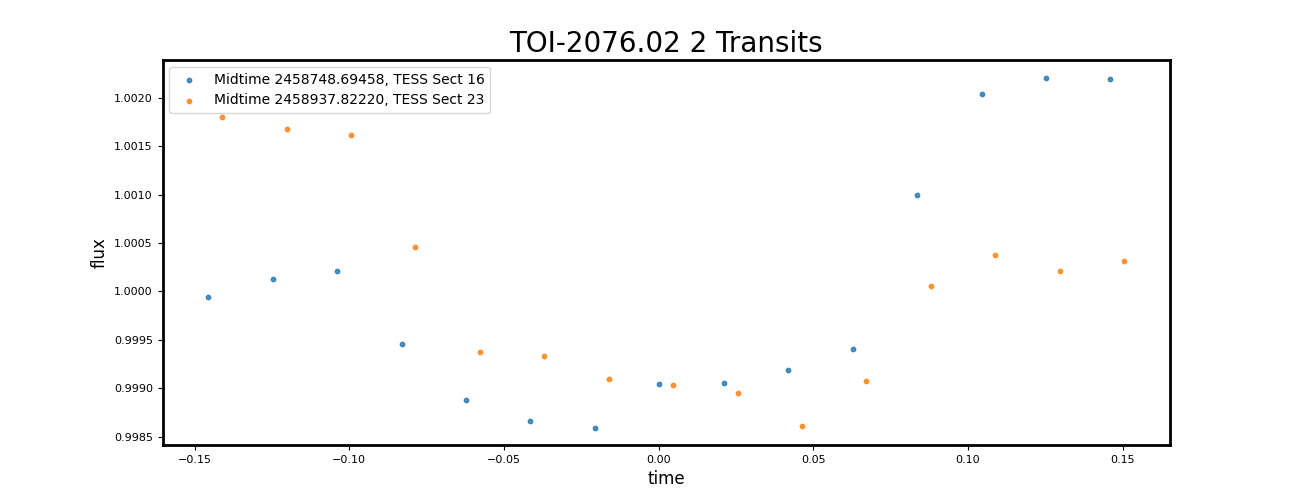

In [17]:
with plt.rc_context({'axes.labelsize': 12 , 'axes.linewidth': 2, 'xtick.labelsize': 8, 'ytick.labelsize': 8, 'legend.fontsize': 10, 'axes.titlesize': 20}):
    my_planet.phase_plot()

In [15]:
my_planet.transit_duration

0.12

In [16]:
my_planet.transit_edge_limit = my_planet.transit_duration/2
my_planet.P_max = None
my_planet.possible_periods()



Provided 2 midtimes, and calculated the maximum period: 189.13 and midtime reference: 2458937.82


In [17]:
my_planet.all_possible_periods_df

,n_order,period,period_err,missed_transits_total
0,1.0,189.130000,0.141421,0.0
1,2.0,94.565000,0.070711,0.0
2,3.0,63.043333,0.047140,0.0
3,4.0,47.282500,0.035355,0.0
4,5.0,37.826000,0.028284,0.0
5,6.0,31.521667,0.023570,0.0
6,7.0,27.018571,0.020203,0.0
7,8.0,23.641250,0.017678,0.0
8,9.0,21.014444,0.015713,0.0
9,10.0,18.913000,0.014142,0.0


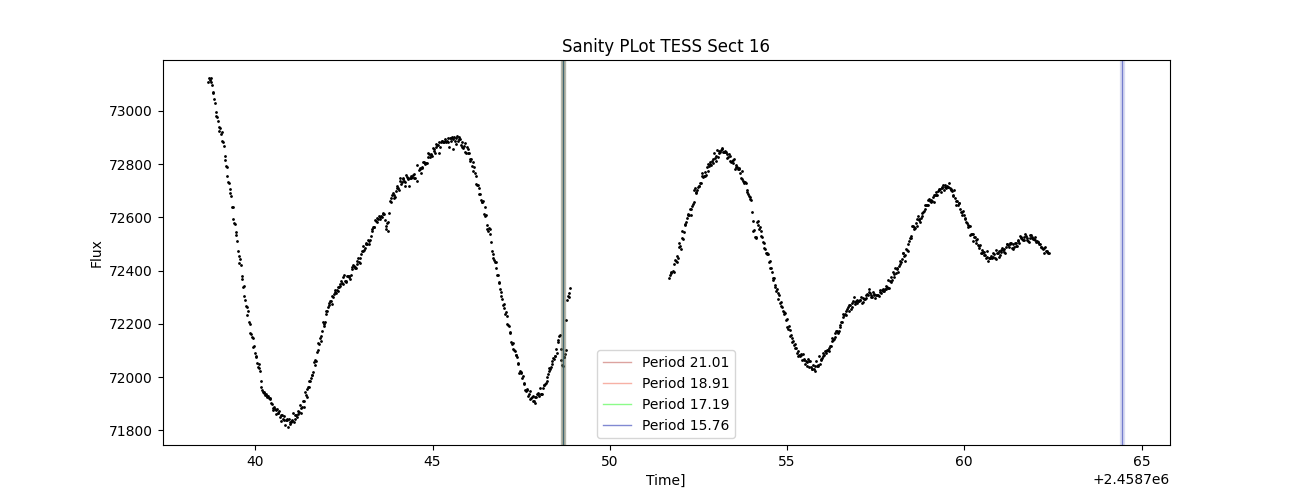

In [14]:
my_planet.sanity_plot([9, 10, 11, 12],0)

In [15]:
periods2use = my_planet.all_possible_periods_df.query('missed_transits_total== 0')

my_planet.setup_possible_periods(periods2use)




In [16]:
my_planet.possible_periods_df

,n_order,period,period_err,missed_transits_total
0,1.0,189.130000,0.141421,0.0
1,2.0,94.565000,0.070711,0.0
2,3.0,63.043333,0.047140,0.0
3,4.0,47.282500,0.035355,0.0
4,5.0,37.826000,0.028284,0.0
5,6.0,31.521667,0.023570,0.0
6,7.0,27.018571,0.020203,0.0
7,8.0,23.641250,0.017678,0.0
8,9.0,21.014444,0.015713,0.0
9,10.0,18.913000,0.014142,0.0


In [39]:
my_planet.obs_bias_period_prob(N_transits=2)


In [40]:
my_planet.possible_periods_df

,n_order,period,period_err,missed_transits_total,obs_bias_period_prob,final_prob_period,N_is_transit,N_no_transit,prob_is_transit
0,1.0,189.130000,0.141421,0.0,0.0685,0.020695,11.0,0.0,1.000000
1,2.0,94.565000,0.070711,0.0,0.1370,0.041389,5.0,6.0,0.455859
2,3.0,63.043333,0.047140,0.0,0.2055,0.062084,3.0,8.0,0.295366
3,4.0,47.282500,0.035355,0.0,0.2740,0.082806,2.0,9.0,0.179729
4,5.0,37.826000,0.028284,0.0,0.3425,0.103500,2.0,9.0,0.214018
5,6.0,31.521667,0.023570,0.0,0.4110,0.124223,1.0,10.0,0.124223
6,7.0,27.018571,0.020203,0.0,0.4857,0.141532,1.0,10.0,0.141532
7,8.0,23.641250,0.017678,0.0,0.5976,0.096923,1.0,10.0,0.096923
8,9.0,21.014444,0.015713,0.0,0.3101,0.109059,1.0,10.0,0.109059
9,10.0,18.913000,0.014142,0.0,0.1998,0.110518,1.0,10.0,0.110518


In [41]:

prior_prob = np.ones(len(my_planet.possible_periods_df))
#########################################################################################
### STAR COORDINTES ###
STAR_RA = pp['RA']
STAR_DEC = pp['DEC']
my_planet.prior_prob_period = prior_prob
# my_planet.setup_probability_period()
my_planet.best_assumed_period()


11
Provided maximum period of 189.13 and midtime reference of 2458937.82
all the periods will be used for the calculation, if not provide a dataframe
Provided maximum period of 94.56 and midtime reference of 2458937.82
all the periods will be used for the calculation, if not provide a dataframe
Provided maximum period of 63.04 and midtime reference of 2458937.82
all the periods will be used for the calculation, if not provide a dataframe
Provided maximum period of 47.28 and midtime reference of 2458937.82
all the periods will be used for the calculation, if not provide a dataframe
Provided maximum period of 37.83 and midtime reference of 2458937.82
all the periods will be used for the calculation, if not provide a dataframe
Provided maximum period of 31.52 and midtime reference of 2458937.82
all the periods will be used for the calculation, if not provide a dataframe
Provided maximum period of 27.02 and midtime reference of 2458937.82
all the periods will be used for the calculation, i

In [42]:
my_planet.possible_periods_df

,n_order,period,period_err,missed_transits_total,obs_bias_period_prob,final_prob_period,N_is_transit,N_no_transit,prob_is_transit
0,1.0,189.130000,0.141421,0.0,0.0685,0.021709,11.0,0.0,1.000000
1,2.0,94.565000,0.070711,0.0,0.1370,0.043418,5.0,6.0,0.513215
2,3.0,63.043333,0.047140,0.0,0.2055,0.065126,3.0,8.0,0.293655
3,4.0,47.282500,0.035355,0.0,0.2740,0.086835,2.0,9.0,0.276225
4,5.0,37.826000,0.028284,0.0,0.3425,0.108544,2.0,9.0,0.171864
5,6.0,31.521667,0.023570,0.0,0.4110,0.130253,1.0,10.0,0.130253
6,7.0,27.018571,0.020203,0.0,0.4857,0.153927,1.0,10.0,0.153927
7,8.0,23.641250,0.017678,0.0,0.5976,0.189390,1.0,10.0,0.189390
8,9.0,21.014444,0.015713,0.0,0.3101,0.098276,1.0,10.0,0.098276
9,10.0,18.913000,0.014142,0.0,0.1998,0.063320,1.0,10.0,0.063320


In [43]:
my_planet.all_transits_multiple_periods([[OBSERV_START,OBSERV_END]],tw = 1/24)
my_planet.initialize_star(STAR_RA,STAR_DEC)
my_planet.initalize_observatory_locations([[OBS_LAT,OBS_LONG,OBS_ALT, 'TEIDE'], [OBS_LAT1,OBS_LONG1,OBS_ALT1, 'MAUNA KEA'], [34.55, 32.57, 1411, 'CYPRUS'], [40.51, 23.37, 800, 'HOLOMODAS']])

Observation start JD:  2460949.5
Observation end JD:  2460976.5
[2460955.20666667 2460970.9675     2460964.21285714 2460976.22111111
 2460961.511      2460966.66909091]
RA = 217.392016 deg degrees, dec = 39.790399 deg degrees, I hope you didnt mess up
Observatory TEIDE: lat = 28.30 degrees, long = -16.51 degrees, height = 2400.00 m
Observatory MAUNA KEA: lat = 19.82 degrees, long = -155.48 degrees, height = 4205.00 m
Observatory CYPRUS: lat = 34.55 degrees, long = 32.57 degrees, height = 1411.00 m
Observatory HOLOMODAS: lat = 40.51 degrees, long = 23.37 degrees, height = 800.00 m


In [44]:
my_planet.observable_transits_multiple_periods(min_h_horizon=10, min_moon_separation = 0)

 (2790750.08605498, -4884714.1484861 , 3000269.26291012)] m, obsgeovel=[(379.70524967, 154.58833852, -0.95870992),
 (356.20633842, 202.95512247, -0.90162287)] m / s)>. Angular separation can depend on the direction of the transformation. [astropy.coordinates.baseframe]
 (-5663668.75382508, 1984671.78294051, 2164963.51300484)] m, obsgeovel=[(-197.57884285, -390.89906585, 0.51089666),
 (-144.71797722, -413.39606089, 0.37913413)] m / s)>. Angular separation can depend on the direction of the transformation. [astropy.coordinates.baseframe]
 (5168062.45301726, -1025743.09543678, 3584745.90763092)] m, obsgeovel=[(123.40275203, 363.17684026, -0.32370699),
 ( 74.80826365, 376.20399264, -0.20228229)] m / s)>. Angular separation can depend on the direction of the transformation. [astropy.coordinates.baseframe]
 (4561066.06580066, -1696459.12519666, 4110360.05832402)] m, obsgeovel=[(166.0869987 , 312.79798177, -0.42885319),
 (123.71898039, 331.84508712, -0.32328481)] m / s)>. Angular separation c

6
0
1
2
3
4
5
[0, 0, 0, 0, 0, 0]
6
6
0
1
2
3
4
5
[0, 0, 0, 0, 0, 0]
6
6
0
1
2
3
4
5
[0, 0, 0, 0, 0, 0]
6
6
0
1
2
3
4
5
[0, 0, 0, 0, 0, 0]
6


 2460970.94916667 2460970.97       2460970.99083333 2460971.01166667
 2460971.0325     2460971.05333333], obsgeoloc=[(-5072242.7857716 , -1359521.01565024, 3610467.74928027),
 (-4850580.55240899, -2012873.24175807, 3609935.07636988),
 (-4545313.6108847 , -2631593.77838778, 3609191.04546388),
 (-4161693.76133037, -3205038.18230909, 3608248.45669535),
 (-3706320.78420456, -3723340.93908496, 3607123.52634434),
 (-3187028.89793116, -4177585.18899166, 3605835.60785415),
 (-2612751.979316  , -4559956.13232062, 3604406.85887311),
 (-1993369.86548416, -4863875.47488357, 3602861.86005034),
 (-1339538.38155331, -5084114.60072555, 3601227.1921436 ),
 ( -662506.01824035, -5216884.52502713, 3599530.97871479)] m, obsgeovel=[( 99.1473019 , -370.53412002, -0.23535355),
 (146.79034498, -354.37020913, -0.35566263),
 (191.90801279, -332.10972719, -0.469853  ),
 (233.72410275, -304.13564264, -0.57596006),
 (271.5192125 , -270.92922053, -0.67215823),
 (304.64311648, -233.06174282, -0.75679245),
 (332.52595

In [45]:
trandf = my_planet.all_transits_df.copy()

In [46]:
trandf

,Date_obs,midtime_obs (UT),midtime_err_min,N_periods,affiliated_periods,prob_is_transit,start_transit,end_trasnit,midtransit_isot,midtimes (BJD),midtimes_err,start_obs,end_obs,TEIDE,MAUNA KEA,CYPRUS,HOLOMODAS
0,2025-10-06,16:57:36.000,2176.999770,3.0,63.04-31.52-21.01-,0.293655,2025-10-06T15:31:12.000,2025-10-06T18:24:00.000,2025-10-06T16:57:36.000,2.460955e+06,1.511805,2460955.1049999986,2460955.3083333317,0,0,0,0
1,2025-10-13,00:15:50.400,2183.773175,1.0,18.91-,0.063320,2025-10-12T22:49:26.400,2025-10-13T01:42:14.400,2025-10-13T00:15:50.400,2.460962e+06,1.516509,2460961.409333332,2460961.612666665,0,0,0,0
2,2025-10-15,17:06:30.857,2186.676091,1.0,27.02-,0.153927,2025-10-15T15:40:06.857,2025-10-15T18:32:54.857,2025-10-15T17:06:30.857,2.460964e+06,1.518525,2460964.111190475,2460964.314523808,0,0,0,0
3,2025-10-18,04:03:29.454,2189.315120,1.0,17.19-,0.039203,2025-10-18T02:37:05.454,2025-10-18T05:29:53.454,2025-10-18T04:03:29.454,2.460967e+06,1.520358,2460966.567424241,2460966.770757574,0,0,0,0
4,2025-10-22,11:13:12.000,2193.933454,2.0,47.28-23.64-,0.276225,2025-10-22T09:46:48.000,2025-10-22T12:39:36.000,2025-10-22T11:13:12.000,2.460971e+06,1.523565,2460970.865833332,2460971.069166665,0,0,0,0
5,2025-10-27,17:18:24.000,2199.578141,1.0,21.01-,0.098276,2025-10-27T15:52:00.000,2025-10-27T18:44:48.000,2025-10-27T17:18:24.000,2.460976e+06,1.527485,2460976.1194444434,2460976.3227777765,0,0,0,0


In [47]:
## find black body equilibrium temperature
def semi_major_axis(P, M_s):
    return ((6.67*10**(-11)*(M_s*1.919*10**30)*(P*24*60*60)**2)/4/(np.pi)**2)**(1/3)/(6.96*10**8)

radius_sun = 0.94
mass_sun = 1.015
temp_star = 5798

temps = []
for per in my_planet.possible_periods_values:
    a = semi_major_axis(per,mass_sun)
    temp = temp_star*np.sqrt(radius_sun/(2*a))
    temps.append(temp)

In [48]:
colors_label = ['T>800', '400<T<800', '270<T<400', 'T<270']
colors_list = ['#FB4B37', '#A47F3D','#3ADCC6', '#148BA7']
colors_periods = []

xi = np.array(list(my_planet.possible_periods_df['period']))
yi = np.array(list(100*my_planet.possible_periods_df['final_prob_period']))

xil = [[], [], [], []]
yil = [[], [], [], []]

for i,temp in enumerate(temps):
    if temp < 270:
        xil[3].append(xi[i])
        yil[3].append(yi[i])
    elif temp < 400:
        xil[2].append(xi[i])
        yil[2].append(yi[i])
    elif temp < 800:
        xil[1].append(xi[i])
        yil[1].append(yi[i])
    else:
        xil[0].append(xi[i])
        yil[0].append(yi[i])



In [49]:
my_planet.possible_periods_values

array([189.13      ,  94.565     ,  63.04333333,  47.2825    ,
        37.826     ,  31.52166667,  27.01857143,  23.64125   ,
        21.01444444,  18.913     ,  17.19363636])

Text(0, 0.5, '% Probability')

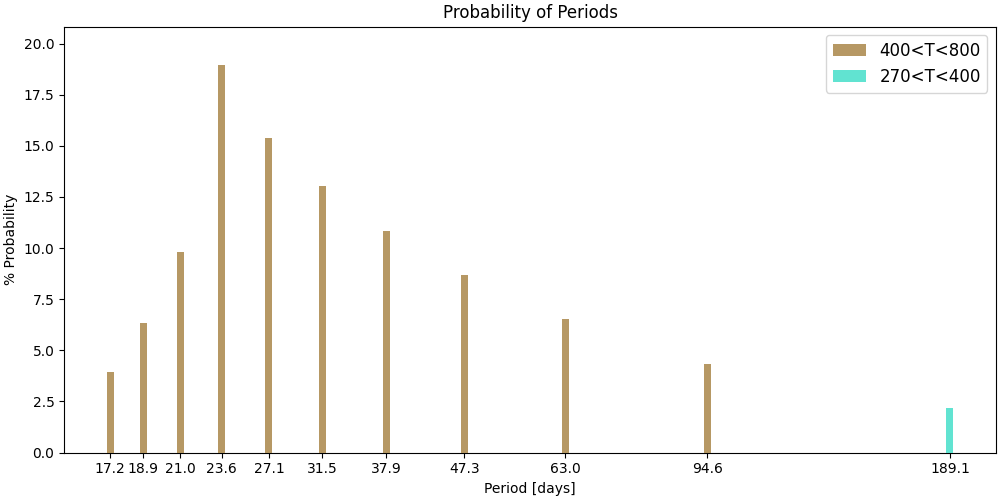

In [50]:
from matplotlib.ticker import ScalarFormatter


# create a dark grey figure
fig, ax = plt.subplots(figsize=(10,5), constrained_layout=True)

for i, x in enumerate(xil):
    if len(x) > 0:
        bars = ax.bar(
            x = xil[i],
            height=yil[i],
            color = colors_list[i],
            alpha = 0.8, zorder = 400,
            width = np.array(xil[i])/50, 
            label = colors_label[i]
            )
#

ax.set_xscale('log')

ax.xaxis.set_major_formatter(ScalarFormatter())
ax.minorticks_off()


ax.set_xticks([189.13,  94.57, 63.04, 47.28, 37.85, 31.52,  27.09,  23.64, 21.01,  18.91,  17.19])

ax.set(ylim=(0,1.1*max(yi)))
plt.legend(fontsize="12")
ax.set_title('Probability of Periods')
ax.set_xlabel('Period [days]')
ax.set_ylabel('% Probability')





In [68]:
pers, trdf = my_planet.max_P_coverage(N_observations = 6,  max_N_periods=35)

0
1
2
3
4
5
If we observe these 5 transits, we observe in total 8/11 period orders, with probability to see transit: 0.83


In [43]:
trdf.sort_values(by = 'start_obs', inplace=True)
trdf.reset_index(drop = True, inplace=True)


In [44]:
trdf

,Date_obs,midtime_obs (UT),midtime_err_min,N_periods,affiliated_periods,prob_is_transit,start_transit,end_trasnit,midtransit_isot,midtimes (BJD),midtimes_err,start_obs,end_obs,TEIDE,MAUNA KEA,CYPRUS,HOLOMODAS
0,2025-10-05,08:26:16.072,1.185541,1.0,23.1-,0.063522,2025-10-05T07:14:16.073,2025-10-05T09:38:16.072,2025-10-05T08:26:16.072,2.460954e+06,0.000823,2460953.759908247,2460953.9432415795,0,0,0,0
1,2025-10-06,05:45:51.685,1.186149,1.0,27.55-,0.066981,2025-10-06T04:33:51.685,2025-10-06T06:57:51.685,2025-10-06T05:45:51.685,2.460955e+06,0.000824,2460954.6485148696,2460954.8318482023,0,0,0,0
2,2025-10-07,13:14:47.112,1.187048,1.0,34.11-,0.027313,2025-10-07T12:02:47.112,2025-10-07T14:26:47.112,2025-10-07T13:14:47.112,2.460956e+06,0.000824,2460955.9602675033,2460956.143600836,0,0,0,0
3,2025-10-09,16:24:17.182,1.188512,1.0,44.76-,0.020226,2025-10-09T15:12:17.182,2025-10-09T17:36:17.182,2025-10-09T16:24:17.182,2.460958e+06,0.000825,2460958.0918655326,2460958.275198865,0,0,0,0
4,2025-10-11,08:11:40.570,1.189653,1.0,26.53-,0.065741,2025-10-11T06:59:40.570,2025-10-11T09:23:40.570,2025-10-11T08:11:40.570,2.460960e+06,0.000826,2460959.7497751107,2460959.9331084434,0,0,0,0
5,2025-10-13,18:04:14.588,1.191316,3.0,65.11-32.56-21.7-,0.101495,2025-10-13T16:52:14.588,2025-10-13T19:16:14.588,2025-10-13T18:04:14.588,2.460962e+06,0.000827,2460962.161279952,2460962.344613285,0,0,0,0
6,2025-10-17,13:59:29.793,1.193967,2.0,42.13-21.07-,0.070496,2025-10-17T12:47:29.793,2025-10-17T15:11:29.793,2025-10-17T13:59:29.793,2.460966e+06,0.000829,2460965.9913170533,2460966.174650386,0,0,0,0
7,2025-10-24,14:30:47.670,1.198856,5.0,119.37-59.68-39.79-29.84-23.87-,0.163288,2025-10-24T13:18:47.670,2025-10-24T15:42:47.670,2025-10-24T14:30:47.670,2.460973e+06,0.000833,2460973.0130517385,2460973.196385071,0,0,0,0
